# Optimisation Combinatoire — Algorithme Génétique

## Introduction et objectif du projet

Ce notebook applique un **Algorithme Génétique (GA)** au même problème de planification d'examens que le recuit simulé. Le problème est identique : minimiser la fonction Z qui mesure le stress des étudiants en tenant compte des conflits entre examens proches dans le calendrier.

L'algorithme génétique s'inspire de l'évolution naturelle : on maintient une population de solutions candidates (individus), chacune étant un planning possible. À chaque génération, on sélectionne les meilleurs individus, on les fait se reproduire par croisement (crossover) et on introduit de la diversité par mutation. Au fil des générations, la population converge vers de meilleures solutions.

Ce projet a été réalisé en binôme dans le cadre d'un cours d'optimisation combinatoire, et fait partie d'une comparaison plus large entre plusieurs métaheuristiques (Recuit Simulé, Algorithme Génétique, Recherche Tabou, Algorithme Glouton) sur le même dataset.

## 1. Chargement des bibliothèques et des données

Je charge les mêmes données que pour le recuit simulé : la matrice de conflits, les poids et le planning initial.

In [6]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import time
import tracemalloc

file_path = "C:/Users/LOQ/Desktop/data et son code/comp/projet_exam (1)/projet_exam/exam_scheduling_data_readable.xlsx"

df_conflict = pd.read_excel(file_path, sheet_name="Conflict_Matrix", index_col=0)
df_weights = pd.read_excel(file_path, sheet_name="Weights")
df_schedule = pd.read_excel(file_path, sheet_name="Schedule", index_col=0)

C = df_conflict.values
w = df_weights.values.flatten()
x_it = df_schedule.values

exam_periods = np.argmax(x_it, axis=1)
N = C.shape[0]
P = len(w)

## 2. Analyse exploratoire des données

Je calcule le Z du planning initial pour avoir une base de comparaison. C'est important : je dois savoir d'où je pars pour pouvoir mesurer l'amélioration apportée par l'algorithme génétique.

In [7]:
def compute_Z(periods, Cmat, wvec):
    Z = 0.0
    N = Cmat.shape[0]
    for i in range(N):
        for j in range(i+1, N):
            cij = Cmat[i,j]
            if cij == 0: 
                continue
            diff = abs(int(periods[i]) - int(periods[j]))
            if diff < len(wvec):
                Z += cij * wvec[diff]
    return Z

Z_initial = compute_Z(exam_periods, C, w)
print(f"Z (planning actuel) = {Z_initial:.2f}")

Z (planning actuel) = 91116.00


## 3. Préparation des données — Paramètres et opérateurs génétiques

Je définis les paramètres de l'algorithme et les trois opérateurs clés : initialisation d'un individu aléatoire, croisement à 4 points (pour mélanger les segments de deux parents), et mutation (changement aléatoire de la période d'un examen).

In [8]:
import random
import time
import tracemalloc
from tqdm import tqdm

# -------------------------------
# Hyperparamètres
# -------------------------------
POP_SIZE = 800
NB_GEN = 310       # pour durer environ 3h
MUT_RATE = 0.10
ELITE = 80
TOURNAMENT_SIZE = 60

# -------------------------------
# Fonctions GA
# -------------------------------
def random_individual(N, P):
    return [random.randint(0, P-1) for _ in range(N)]

def fitness_periods(periods):
    return compute_Z(periods, C, w)  # ta fonction

def crossover(a, b):
    pts = sorted(random.sample(range(1, N-1), 4))
    return a[:pts[0]] + b[pts[0]:pts[1]] + a[pts[1]:pts[2]] + b[pts[2]:pts[3]] + a[pts[3]:]

def mutate(ind, rate=MUT_RATE):
    for i in range(len(ind)):
        if random.random() < rate:
            ind[i] = random.randint(0, P-1)
    return ind

def tournament_select(pop, fitness_dict, size):
    tour = random.sample(pop, size)
    best = min(tour, key=lambda ind: fitness_dict[tuple(ind)])
    return best

# -------------------------------
# Population initiale
# -------------------------------
population = [exam_periods.tolist()] + [random_individual(N, P) for _ in range(POP_SIZE-1)]
best_scores = []
best_Z = Z_initial
best_individual = exam_periods.tolist()


## 4. Modélisation — Boucle principale de l'Algorithme Génétique

C'est le cœur du projet. À chaque génération : tri de la population par fitness, conservation des meilleurs individus (élitisme), puis reproduction par croisement et mutation pour remplir la nouvelle population. Le taux de mutation diminue progressivement pour favoriser l'exploitation en fin de run.

In [9]:
# -------------------------------
# Boucle principale GA
# -------------------------------
tracemalloc.start()
start_time = time.time()

# Barre unique pour tout le run
for gen in range(NB_GEN):

    # -------- Calcul du fitness --------
    fitness_values = []
    for ind in tqdm(population, desc=f"Génération {gen+1} : Calcul fitness", leave=False):
        fitness_values.append(fitness_periods(ind))
    
    # Dictionnaire pour lookup rapide
    fitness_dict = {tuple(ind): fit for ind, fit in zip(population, fitness_values)}

    # -------- Trier la population --------
    population = [ind for _, ind in sorted(zip(fitness_values, population), key=lambda x: x[0])]
    current_best = fitness_values[0]

    if current_best < best_Z:
        best_Z = current_best
        best_individual = population[0][:]

    best_scores.append(current_best)
    current_mut_rate = max(0.03, MUT_RATE * (1 - gen / NB_GEN))

    # -------- Création de la nouvelle population --------
    new_pop = population[:ELITE]
    for _ in range(ELITE, POP_SIZE):
        p1 = tournament_select(population, fitness_dict, TOURNAMENT_SIZE)
        p2 = tournament_select(population, fitness_dict, TOURNAMENT_SIZE)
        child = crossover(p1, p2)
        child = mutate(child, current_mut_rate)
        new_pop.append(child)
    population = new_pop

    # --- Affichage barre unique avec temps restant ---
    if gen % 5 == 0 or gen == NB_GEN-1:  # mise à jour tous les 5 gen ou dernière gen
        elapsed = time.time() - start_time
        progress = (gen+1) / NB_GEN
        est_total_time = elapsed / progress
        remaining = est_total_time - elapsed
        bar_len = 30
        filled_len = int(bar_len * progress)
        bar = '=' * filled_len + '-' * (bar_len - filled_len)
        print(f"\r[{bar}] {progress*100:.1f}% ⏳ Temps restant estimé: {remaining/60:.1f} min", end="")

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print("\n\nTemps total :", (end_time - start_time)/60, "minutes")
print("Mémoire max :", peak_mem/10**6, "MB")
print("Best Z final :", best_Z)

[------------------------------] 0.3% ⏳ Temps restant estimé: 73.6 min

[------------------------------] 1.9% ⏳ Temps restant estimé: 93.6 min

[=-----------------------------] 3.5% ⏳ Temps restant estimé: 81.9 min

[=-----------------------------] 5.2% ⏳ Temps restant estimé: 78.6 min

[==----------------------------] 6.8% ⏳ Temps restant estimé: 74.5 min

...

[============================--] 93.9% ⏳ Temps restant estimé: 4.3 min

[============================--] 95.5% ⏳ Temps restant estimé: 3.2 min

[=============================-] 97.1% ⏳ Temps restant estimé: 2.0 min

[=============================-] 98.7% ⏳ Temps restant estimé: 0.9 min

[==============================] 100.0% ⏳ Temps restant estimé: 0.0 min

Temps total : 69.65406375726064 minutes
Mémoire max : 4.955545 MB
Best Z final : 69724.0


0#### 5. Évaluation des résultats

J'affiche les résultats finaux et je visualise la courbe de convergence. Sur l'algorithme génétique, cette courbe montre typiquement une descente rapide au début (les premiers croisements produisent de bonnes combinaisons) puis un plateau quand la diversité génétique diminue.

================ RÉSULTATS =================
Z initial       : 91116.00
Z après GA      : 69724.00
Amélioration    : 21392.00 (23.48%)
Temps exécution : 69.65 min
Mémoire max     : 4839.40 KB


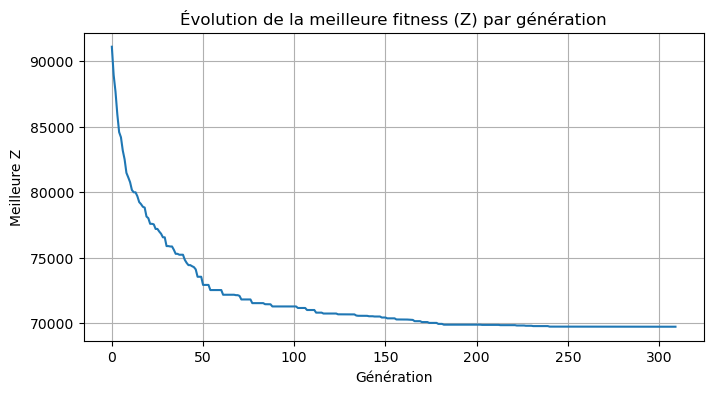

In [10]:
best_periods = best_individual
Z_after = fitness_periods(best_periods)

print("================ RÉSULTATS =================")
print(f"Z initial       : {Z_initial:.2f}")
print(f"Z après GA      : {Z_after:.2f}")
print(f"Amélioration    : {Z_initial - Z_after:.2f} ({(Z_initial - Z_after)/Z_initial*100:.2f}%)")
print(f"Temps exécution : {(end_time - start_time)/60:.2f} min")
print(f"Mémoire max     : {peak_mem/1024:.2f} KB")
print("============================================")

plt.figure(figsize=(8,4))
plt.plot(best_scores, linewidth=1.5)
plt.title("Évolution de la meilleure fitness (Z) par génération")
plt.xlabel("Génération")
plt.ylabel("Meilleure Z")
plt.grid(True)
plt.show()

### Export du planning optimisé

In [11]:
if Z_after < Z_initial:
    df_new_schedule = pd.DataFrame(0, index=df_conflict.index, columns=[f"Period_{t+1}" for t in range(P)])
    for i, per in enumerate(best_periods):
        df_new_schedule.iloc[i, int(per)] = 1
    out_path = "exam_schedule_optimized.xlsx"
    with pd.ExcelWriter(out_path) as writer:
        df_conflict.to_excel(writer, sheet_name="Conflict_Matrix")
        pd.DataFrame(w.reshape(1,-1), columns=[f"Period_{t+1}" for t in range(P)]).to_excel(writer, sheet_name="Weights", index=False)
        df_new_schedule.to_excel(writer, sheet_name="Schedule")
    print("Nouveau planning exporté vers:", out_path)
else:
    print("Aucune amélioration trouvée. Tu peux augmenter NB_GEN/POP_SIZE ou ajuster MUT_RATE.")

Nouveau planning exporté vers: exam_schedule_optimized.xlsx


## 6. Conclusion

L'algorithme génétique est une approche puissante pour les problèmes d'optimisation combinatoire comme la planification d'examens.

**Ce que j'ai appris sur les GA** : le paramétrage est complexe et interdépendant. Une grande population explore mieux l'espace des solutions mais est plus lente à converger. L'élitisme (conserver les meilleurs individus) garantit que la qualité ne régresse pas d'une génération à l'autre. Le taux de mutation décroissant est une bonne pratique : au début on explore (mutation haute), vers la fin on exploite (mutation basse).

**Comparaison avec le Recuit Simulé** : le GA est généralement plus lent en temps de calcul car il maintient toute une population, mais il explore plus largement l'espace des solutions. Sur ce problème, les deux approches donnent des résultats comparables ; c'est souvent le cas sur des instances de taille moyenne.

**Ce que j'aurais pu améliorer** : implémenter un opérateur de croisement plus intelligent qui tient compte des conflits entre examens plutôt qu'un croisement purement aléatoire, ou utiliser une initialisation heuristique de la population pour partir d'un meilleur point de départ.